# **Assignment 1: Optimization In The Hospital**


---


**Author**: Lorena Torres Jiménez

**NIA**: 100475834

**DATE**: December 20th, 2025; Master in Big Data Analytics UC3M

The efficient management of hospital resources is a current critical challenge in hospital operations, which directly impacts in the patient care quality, as well as in the organizational costs. Henceforth, the main objective is to apply mathematical optimization techniques for solving an essential resource allocation problem within the framework of a major public hospital.

By strategically distributing limited resources, such as specialized personnel, across multiple departments and work shifts, and different groups of patients, the total weighted effectiveness of patient care can be maximized. The problem formulation incorporates realistic operational constraints, including personnel availability, budget limitations, and minimum service requirements, which will be described in detail in the subsequent sections.

## **Formulation Of The Primal Model**


---

For the formulation of the primal problem, some sets will be used, for simplification purposes:
 - $D = \{1, \ldots, 5\}$ for departments (ER, ICU, Surgery, Pediatrics, General)
 - $T = \{1, 2\}$ for type of workers (Doctors, Nurses)
 - $S = \{1, \ldots, 3\}$ for shifts (Morning, Afternoon, Night)
 - $P = \{1, \ldots, 4\}$ for patients groups by severity (Low, Minor, Major, Critical)

<br>

 Moreover, there are different parameters to be accounted for, such as:
 - $demand_{d,s,p}$: minimal attention demand of the department $d$ during the shift $s$ because of the patient severity $p$
 - $weight_p$: clinical weight of the severity of the patient $p$
 - $efficiency_t$: efficiency of the type of worker $t$
 - $capacity_{d,s,t}$: available hours of the type of workers $t$ in department $d$ per shift $s$
 - $cost_t$: cost per hour of type of worker $t$
 - $budget$: total available budget, which may be also defined as the cost limit

<br>

 Afterwards, variables should be also defined, so that:
 - $x_{d,s,t,p} ≥ 0$: Hours of attention of the type of worker $t$ to the group of patients $p$, in the department $d$ during the shift $s$

 <br>

 Then, the objective function is based on maximizing the effective weighted total attention. Hencefoth, it may be defined as:

<br>

 $$\text{max Z} = \sum_{d \in D} \sum_{s \in S} \sum_{t \in T} \sum_{p \in P} weight_p ⋅ \text{efficiency}_t ⋅ x_{d,s,t,p}$$

<br>

 Lastly, constraints also need to be defined:
 - Minimum attention demand:$\sum_t x_{d,s,t,p} \ge \text{demand}_{d,s,p}$ , $\forall d,s,p$
 - Workers capacity:$\sum_p x_{d,s,t,p} \le \text{capacity}_{d,s,t}$ , $∀ d,s,t$
 - Total budget: $∑_{d,s,t,p} \text{cost}_t \cdot x_{d,s,t,p} ≤ \text{budget}$
 - Non-negativity: $x_{d,s,t,p}$, $∀d,r,s$

## **Resolution Of Primal Model**


---

Firstly, the libraries employed, Pyomo and the GLPK solver were loaded.

In [1]:
!apt-get install -y -qq glpk-utils
!pip install -q pyomo

In [2]:
import random
import time
import math
import numpy as np
from pyomo.environ import *
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
SolverFactory("glpk").available()

True

In [4]:
solver = SolverFactory('glpk')

In [5]:
random.seed(12345); np.random.seed(12345)

Then, the data of the problem was defined, including the sets of the model, $D$, $T$, $S$ and $P$, and its parameters.

However, even though the sets were predefined, some parameters were randomly generated, except from the efficiency, cost and budget.

In [6]:
model = ConcreteModel()

# Sets
model.D = RangeSet(1,5)   # Departments
model.S = RangeSet(1,3)   # Shifts
model.T = RangeSet(1,2)   # Staff types
model.P = RangeSet(1,4)   # Patient groups

# Parameters
weight = {p: random.uniform(1.0, 3.0) for p in model.P}
efficiency = {1: 1.2, 2: 0.8}   # 1: doctors, 2: nurses
cost = {1: 80, 2: 40}           # €/hour
budget = 50000
demand = {(d,s,p): random.uniform(6,15)
          for d in model.D for s in model.S for p in model.P}
capacity = {(d,s,t): random.uniform(25,40)
            for d in model.D for s in model.S for t in model.T}


Then, the primal model was designed, as its main goal was the maximization of the total weighted service under different previously-defined constraints.

In [7]:
#Model and objective function
model.x = Var(model.D, model.S, model.T, model.P,
              domain=NonNegativeReals)

def obj_rule(model):
    return sum(weight[p] * efficiency[t] * model.x[d,s,t,p]
               for d in model.D
               for s in model.S
               for t in model.T
               for p in model.P)

model.obj = Objective(rule=obj_rule, sense=maximize)


#Constraints
def demand_rule(model, d, s, p):
    return sum(model.x[d,s,t,p] for t in model.T) >= demand[d,s,p]

model.demand_constraint = Constraint(model.D, model.S, model.P,
                                     rule=demand_rule)
def capacity_rule(model, d, s, t):
    return sum(model.x[d,s,t,p] for p in model.P) <= capacity[d,s,t]

model.capacity_constraint = Constraint(model.D, model.S, model.T,
                                       rule=capacity_rule)
def budget_rule(model):
    return sum(cost[t] * model.x[d,s,t,p]
               for d in model.D
               for s in model.S
               for t in model.T
               for p in model.P) <= budget

model.budget_constraint = Constraint(rule=budget_rule)

#For further sensitivity analysis
model.dual = Suffix(direction=Suffix.IMPORT)

After the model was designed, the solution of it was printed, obtaining the following output:

In [8]:
results = solver.solve(model, tee=True)
print("Optimal objective value:", value(model.obj))

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmp8srnfs0c.glpk.raw --wglp /tmp/tmpnxtzc5sd.glpk.glp --cpxlp
 /tmp/tmp__1ih33j.pyomo.lp
Reading problem data from '/tmp/tmp__1ih33j.pyomo.lp'...
91 rows, 120 columns, 360 non-zeros
882 lines were read
Writing problem data to '/tmp/tmpnxtzc5sd.glpk.glp'...
785 lines were written
GLPK Simplex Optimizer 5.0
91 rows, 120 columns, 360 non-zeros
Preprocessing...
91 rows, 120 columns, 360 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  8.000e+01  ratio =  8.000e+01
GM: min|aij| =  8.409e-01  max|aij| =  1.189e+00  ratio =  1.414e+00
EQ: min|aij| =  7.071e-01  max|aij| =  1.000e+00  ratio =  1.414e+00
Constructing initial basis...
Size of triangular part is 91
      0: obj =  -0.000000000e+00 inf =   5.196e+02 (60)
     73: obj =   9.937173636e+02 inf =   0.000e+00 (0)
*   108: obj =   1.830971372e+03 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.2 Mb (17

The output showed the successful resolution of the primal model. Firstly, the sizes of the model were detailed, having that:

- Rows: They represent the constraints of the model, and in this one, there were 91, including atenttion demand, capacity, and budget constraints.
- Columns: They represent the continuous decision variables, and there were 120 (5 departments x 2 types of workers x 3 shifts x 4 patient groups).
- Non-zeros: They indicate the density of the constraint matrix. There were 360, but compared to the total number of entries (91 x 120 = 10920), it is a low value, so it is a relatively sparse matrix. Note that this may aid solver performance.

Afterwards, preprocessing and scaling was performed for enhancing numerical stability and speed, and the simplex algorithm was implemented. After 16 iterations, the solution was found. The primal objective value is 1830.97137 approximately, which is the maximum achievable weighted service given the constraints. The problem was solved in less than a second and the memory used was 0.2 Mb, so that the computational requirements can be said to be negligible, and thus, the model highly efficient and scalable.

## **Preparation Of Dual Model**


---
The dual model was prepared by extracting the optimal resource allocation plan. Henceforth, the main objective is to translate the mathematical result, the optimal values of the decision variables, by iterating through every possible combination of them. Consequently, by performing a sensitivity analysis, powerful insights are provided by printing its values.

Hence, this will show the marginal value of the resources of the hospital, as well as how the weighted service may change as the budget does.

In [9]:
#Dual for demand restrictions
for d in model.D:
    for s in model.S:
        for p in model.P:
            c = model.demand_constraint[d,s,p]
            print(f"Dual(demand)[{d},{s},{p}] = {model.dual[c]:.2f}")

#Dual for personnel capacity
for d in model.D:
    for s in model.S:
        for t in model.T:
            c = model.capacity_constraint[d,s,t]
            print(f"Dual(capacity)[{d},{s},{t}] = {model.dual[c]:.2f}")

#Dual for budget restrictions
print("Dual(budget) =", model.dual[model.budget_constraint])


Dual(demand)[1,1,1] = -0.65
Dual(demand)[1,1,2] = -1.30
Dual(demand)[1,1,3] = 0.00
Dual(demand)[1,1,4] = -0.84
Dual(demand)[1,2,1] = -0.65
Dual(demand)[1,2,2] = -1.30
Dual(demand)[1,2,3] = 0.00
Dual(demand)[1,2,4] = -0.84
Dual(demand)[1,3,1] = -0.65
Dual(demand)[1,3,2] = -1.30
Dual(demand)[1,3,3] = 0.00
Dual(demand)[1,3,4] = -0.84
Dual(demand)[2,1,1] = -0.65
Dual(demand)[2,1,2] = -1.30
Dual(demand)[2,1,3] = 0.00
Dual(demand)[2,1,4] = -0.84
Dual(demand)[2,2,1] = -0.65
Dual(demand)[2,2,2] = -1.30
Dual(demand)[2,2,3] = 0.00
Dual(demand)[2,2,4] = -0.84
Dual(demand)[2,3,1] = -0.98
Dual(demand)[2,3,2] = -1.63
Dual(demand)[2,3,3] = 0.00
Dual(demand)[2,3,4] = -1.17
Dual(demand)[3,1,1] = -0.65
Dual(demand)[3,1,2] = -1.30
Dual(demand)[3,1,3] = 0.00
Dual(demand)[3,1,4] = -0.84
Dual(demand)[3,2,1] = -0.65
Dual(demand)[3,2,2] = -1.30
Dual(demand)[3,2,3] = 0.00
Dual(demand)[3,2,4] = -0.84
Dual(demand)[3,3,1] = -0.98
Dual(demand)[3,3,2] = -1.63
Dual(demand)[3,3,3] = -0.00
Dual(demand)[3,3,4] = -1.17


By analyzing these results, it may be underlined that the dual budget has a value of 0.03976 approximately, which indicates that by every extra euro that the budget is increased, the objective function should increase by 0.03976 units. Moreover, in some combinations seen above, dual capacity has a null value, thus reflecting that this is not an active constraint, but in other combinations, like where they reach values of 0.53 or 0.86, it is suggested that the capacity is nearly reaching the limit. Lastly, the negative values correspond to the cost in terms of effectiveness, in which there is obligation to fulfill a minimum demand. However, if the minimum demand was decreased, then the total effectiveness may improve, as the model will be "freer" to assign resources to higher priority patients.

## **Formulation Of The Dual Model**


---

For the formulation of the dual problem, the same sets and parameters of the primal model were maintained. However, the dual variables were defined as:
- $\alpha_{d,s,p} \ge 0$ for each minimum demand ($p$, $d$, $s$)
- $\beta_{d,s,t} \ge 0$ for each capacity ($t$, $d$, $s$)
- $\gamma ≥ 0$ for each restriction in the budget

<br>

Then, the objective function is based on minimizing the weighted sum of the constraint (right-hand sides), where the weights are the dual variables:

<br>

$$\text{min Z} = \sum_{d,s,p} \text{demand}_{d,s,p} \cdot \alpha_{d,s,p} + \sum_{d,s,t}\text{capacity}_{d,s,t} \cdot \beta_{d,s,t} + \text{budget}\cdot \gamma$$

<br>

Lastly, dual constraints also need to be defined for ensuring that the total cost of the resources used by a single allocation variable is:
$$\alpha_{d,s,p} + \beta_{d,s,t} + \gamma \cdot \text{cost}_t ≥ \text{weight}_p \cdot \text{efficiency}_t$$
 $$∀ d \in D, s \in S, t \in T, p \in P$$
<br>

With $\alpha_{d,s,p}$, $\beta_{d,s,t}$, and $\gamma$ ≥ 0.

In [10]:
dual_model = ConcreteModel()

#Dual sets
dual_model.D = RangeSet(1,5)
dual_model.S = RangeSet(1,3)
dual_model.T = RangeSet(1,2)
dual_model.P = RangeSet(1,4)

# Dual variables
dual_model.alpha = Var(dual_model.D, dual_model.S, dual_model.P,
                       domain=NonNegativeReals)

dual_model.beta = Var(dual_model.D, dual_model.S, dual_model.T,
                      domain=NonNegativeReals)

dual_model.gamma = Var(domain=NonNegativeReals)

#Objective function

def dual_obj_rule(m):
    return (
        sum(demand[d,s,p] * m.alpha[d,s,p]
            for d in m.D for s in m.S for p in m.P)
        +
        sum(capacity[d,s,t] * m.beta[d,s,t]
            for d in m.D for s in m.S for t in m.T)
        +
        budget * m.gamma
    )

dual_model.obj = Objective(rule=dual_obj_rule, sense=minimize)


#Dual constraints
def dual_constraint_rule(m, d, s, t, p):
    return (
        m.alpha[d,s,p]
        + m.beta[d,s,t]
        + cost[t] * m.gamma
        >= weight[p] * efficiency[t]
    )

dual_model.dual_constraints = Constraint(
    dual_model.D, dual_model.S, dual_model.T, dual_model.P,
    rule=dual_constraint_rule
)

## **Resolution Of Dual Model**


---
The dual model was solved and the results obtained were printed below.

In [11]:
solver = SolverFactory('glpk')
results_dual = solver.solve(dual_model, tee=True)

print("Dual optimal value:", value(dual_model.obj))

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmp9vymazjj.glpk.raw --wglp /tmp/tmpqnz6w25w.glpk.glp --cpxlp
 /tmp/tmppb0jis0u.pyomo.lp
Reading problem data from '/tmp/tmppb0jis0u.pyomo.lp'...
120 rows, 91 columns, 360 non-zeros
911 lines were read
Writing problem data to '/tmp/tmpqnz6w25w.glpk.glp'...
785 lines were written
GLPK Simplex Optimizer 5.0
120 rows, 91 columns, 360 non-zeros
Preprocessing...
120 rows, 91 columns, 360 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  8.000e+01  ratio =  8.000e+01
GM: min|aij| =  8.409e-01  max|aij| =  1.189e+00  ratio =  1.414e+00
EQ: min|aij| =  7.071e-01  max|aij| =  1.000e+00  ratio =  1.414e+00
Constructing initial basis...
Size of triangular part is 120
      0: obj =   0.000000000e+00 inf =   1.756e+02 (120)
      8: obj =   2.650413019e+03 inf =   0.000e+00 (0)
*   138: obj =   1.281963383e+03 inf =   0.000e+00 (0) 1
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.2 Mb

In [12]:
#Checking and comparison
print("Primal optimal value:", value(model.obj))
print("Dual optimal value:", value(dual_model.obj))
print("Primal optimal value - Dual optimal value", value(model.obj)-value(dual_model.obj))

Primal optimal value: 1830.9713721316468
Dual optimal value: 1281.9633829145748
Primal optimal value - Dual optimal value 549.007989217072


The result obtained from the dual model was 1281.96338 approximately, and by substracting this result to the primal model result, the difference is approximately 549.00799, which is a significant duality gap. In many linear programming problems, it is expected that this gap is null, showing a strong duality. However, in this case, the primal value was greater than the dual one, suggesting a weak duality. Henceforth, this may indicates different possibilities, such as:
- Non-convexity of the problem, so the gap is expected to be different from zero, and then, it will represent the cost of the constraints that make the problem non-convex.
- Lack of convergence, so that if the problem is convex, then it is possible that the maximum iteration limit has been reached or tolerance is too loose.
- Relaxation, as the problem may act as a lower bound, indicating that there will not be a better primal solution than this dual one.

Then, this solution also confirms the values obtained in the preparation of the dual model, so that the budget is said to be a critical resource given that its associated dual variable ($\gamma$) is positive, and henceforth, the model will need extra budget for improving the total effectiveness. In relation to computational efficiency, the model was solved in less than 0.1 second, only using 0.2 Mb of memory.

For improving this solution, it will be useful to solve the MILP proposed below.

## **Mixed-Integer Linear Program (MILP)**


---
Mixed-Integer Linear Problems (MILPs) are powerful mathematical optimization methods used to solve complex decision-making problems where some variables must be integers, while other variables can be continuous values. Therefore, it tries to find the best solution for a linear goal that is subjected to linear constraints, by mixing both integer and linear variables.

## **Formulation Of The MILP**


---

For the formulation of the MILP, a new decision variable is introduced:
- $y_{d,s,t} \in \{0,1\}$: A binary variable whose outputs are 1 if the type of worker $t$ is assigned to the shift $s$ in the department $d$, and 0 otherwise

<br>

Then, the objective function is the same one as before, so that it is based on maximizing the net weighted service:

<br>

$$\text{max } Z_{\text{MILP}} = \sum_{d,s,t,p}\text{weight}_p \cdot \text{efficiency}_t \cdot x_{d,s,t,p}$$
<br>

Lastly, linking constraints also need to be defined:
$$\sum_p x_{d,s,t,p} \ge h^{min} \cdot y_{d,s,t}$$
$$\sum_p x_{d,s,t,p} \le M \cdot y_{d,s,t}$$

$$\forall d,s,t$$

Note that M is used because of the Big-M method, so that by being M enough large (in this case M=50), it is ensured that if a resource is not activated (y=0), the hours allocated must be 0 (x ≤ 0) and otherwise, the hours allocated are determined by original attention demand and capacity constraints (x ≤ M).

In [13]:
# Binary variables
model.y = Var(model.D, model.S, model.T, domain=Binary)

# Parameters
M = 50        # Big-M
h_min = 8     # Minimum hours if activated

#Activation constraints
def activation_upper_rule(model, d, s, t):
    return sum(model.x[d,s,t,p] for p in model.P) <= M * model.y[d,s,t]

model.activation_upper = Constraint(
    model.D, model.S, model.T,
    rule=activation_upper_rule
)

#Minimum hours constraint
def activation_lower_rule(model, d, s, t):
    return sum(model.x[d,s,t,p] for p in model.P) >= h_min * model.y[d,s,t]

model.activation_lower = Constraint(
    model.D, model.S, model.T,
    rule=activation_lower_rule
)

## **Resolution Of MILP**


---
The MILP was solved and the results obtained were printed below.

In [14]:
solver = SolverFactory('glpk')
results = solver.solve(model, tee=True)

print("MILP optimal value:", value(model.obj))

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmp3vp52qjv.glpk.raw --wglp /tmp/tmp3g4bs6kw.glpk.glp --cpxlp
 /tmp/tmp4wkrpjuj.pyomo.lp
Reading problem data from '/tmp/tmp4wkrpjuj.pyomo.lp'...
/tmp/tmp4wkrpjuj.pyomo.lp:1393: warning: lower bound of variable 'x214' redefined
/tmp/tmp4wkrpjuj.pyomo.lp:1393: warning: upper bound of variable 'x214' redefined
151 rows, 150 columns, 660 non-zeros
30 integer variables, all of which are binary
1423 lines were read
Writing problem data to '/tmp/tmp3g4bs6kw.glpk.glp'...
1355 lines were written
GLPK Integer Optimizer 5.0
151 rows, 150 columns, 660 non-zeros
30 integer variables, all of which are binary
Preprocessing...
151 rows, 150 columns, 660 non-zeros
30 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  8.000e+01  ratio =  8.000e+01
GM: min|aij| =  6.325e-01  max|aij| =  1.581e+00  ratio =  2.500e+00
EQ: min|aij| =  4.000e-01  max|aij| =  1.000e+00  ratio =  

In [15]:
#May be useful:

for d in model.D:
    for s in model.S:
        for t in model.T:
            if model.y[d,s,t].value > 0.5:
                print(f"Turn ON: Dept {d}, Shift {s}, Staff {t}")

Turn ON: Dept 1, Shift 1, Staff 1
Turn ON: Dept 1, Shift 1, Staff 2
Turn ON: Dept 1, Shift 2, Staff 2
Turn ON: Dept 1, Shift 3, Staff 1
Turn ON: Dept 1, Shift 3, Staff 2
Turn ON: Dept 2, Shift 1, Staff 1
Turn ON: Dept 2, Shift 1, Staff 2
Turn ON: Dept 2, Shift 2, Staff 1
Turn ON: Dept 2, Shift 2, Staff 2
Turn ON: Dept 2, Shift 3, Staff 1
Turn ON: Dept 2, Shift 3, Staff 2
Turn ON: Dept 3, Shift 1, Staff 1
Turn ON: Dept 3, Shift 1, Staff 2
Turn ON: Dept 3, Shift 2, Staff 1
Turn ON: Dept 3, Shift 2, Staff 2
Turn ON: Dept 3, Shift 3, Staff 1
Turn ON: Dept 3, Shift 3, Staff 2
Turn ON: Dept 4, Shift 1, Staff 1
Turn ON: Dept 4, Shift 1, Staff 2
Turn ON: Dept 4, Shift 2, Staff 1
Turn ON: Dept 4, Shift 2, Staff 2
Turn ON: Dept 4, Shift 3, Staff 1
Turn ON: Dept 4, Shift 3, Staff 2
Turn ON: Dept 5, Shift 1, Staff 1
Turn ON: Dept 5, Shift 1, Staff 2
Turn ON: Dept 5, Shift 2, Staff 1
Turn ON: Dept 5, Shift 2, Staff 2
Turn ON: Dept 5, Shift 3, Staff 1
Turn ON: Dept 5, Shift 3, Staff 2


The MILP optimal solution found was 1830.97137. This result confirms that the staffing and shift assignment decisions obtained are sufficient to maximize the objective function while satisfying all operational and labor constraints. Firstly, the solution indicates that the primal result obtained in previous formulations was already near-optimal, since no additional shifts were required to further improve the objective value. Moreover, the introduction of binary variables and the Big-M constraints allowed the model to explicitly enforce labor regulations without sacrificing the quality of care provided. This ensures that all assignments remain feasible under real-world scheduling rules.

Finally, the MILP was solved in less than 0.1 seconds, demonstrating that the inclusion of integer variables does not significantly increase computational complexity for the problem size considered.


## **Relaxed MILP Problem**


---
After solving the MILP problem above, the relaxed version of the problem was proposed, so that some variables, instead of being binary variables in which the possible outcomes are 0 or 1, they may take intermediate values (such as 0.5).

For this purpose, this method is used for 3 main reasons:
- Establishing an upper bound, so that $Z_{relaxed} \ge Z_{integer}$ and it is shown how much profit is lost due to some restrictions like minimum-hour shifts.
- Measuring the gap between the relaxed and non-relaxed version of the problem, as if the gap is too large, then the integrity constraints will be limiting the efficiency. However, if the gap is null, then the solution is optimal and the model is robust.
- Helping the solver to find the solution of the problem.

Although the original MILP does not include a minimum working hours constraint, this condition is introduced in the relaxed formulation to analyze solution robustness.

Firstly, the model was replicated and some parameters were added, like the Big-M and the minimum of hours per shift if activated. Then, some constraints were added and the model was solved.

In [16]:
#Idential to the previous one but modifying:
model.y = Var(model.D, model.S, model.T, bounds=(0,1))

# Parameters
M = 50        # Big-M
h_min = 8     # Minimum hours if activated

#Activation constraints
def activation_upper_rule(model, d, s, t):
    return sum(model.x[d,s,t,p] for p in model.P) <= M * model.y[d,s,t]

model.activation_upper = Constraint(
    model.D, model.S, model.T,
    rule=activation_upper_rule
)

#Minimum hours constraint
def activation_lower_rule(model, d, s, t):
    return sum(model.x[d,s,t,p] for p in model.P) >= h_min * model.y[d,s,t]

model.activation_lower = Constraint(
    model.D, model.S, model.T,
    rule=activation_lower_rule
)

This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


In [17]:
solver = SolverFactory('glpk')
results_relaxed = solver.solve(model, tee=True)

print("Relaxed LP optimal value:", value(model.obj))


GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpw6rf2gc5.glpk.raw --wglp /tmp/tmp6fsnffoe.glpk.glp --cpxlp
 /tmp/tmpkcuy1zjq.pyomo.lp
Reading problem data from '/tmp/tmpkcuy1zjq.pyomo.lp'...
151 rows, 150 columns, 660 non-zeros
1392 lines were read
Writing problem data to '/tmp/tmp6fsnffoe.glpk.glp'...
1265 lines were written
GLPK Simplex Optimizer 5.0
151 rows, 150 columns, 660 non-zeros
Preprocessing...
151 rows, 150 columns, 660 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  8.000e+01  ratio =  8.000e+01
GM: min|aij| =  6.325e-01  max|aij| =  1.581e+00  ratio =  2.500e+00
EQ: min|aij| =  4.000e-01  max|aij| =  1.000e+00  ratio =  2.500e+00
Constructing initial basis...
Size of triangular part is 151
      0: obj =  -0.000000000e+00 inf =   1.792e+02 (60)
    101: obj =   9.937173636e+02 inf =   0.000e+00 (0)
*   142: obj =   1.830971372e+03 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.3 

In order to analyze the behavior of the model when integrality constraints are relaxed, a relaxed MILP formulation was solved. In this version, binary decision variables were relaxed to continuous variables, and a minimum working hours constraint of $h^{min} = 8$ was introduced using a Big-M formulation. The optimal objective value obtained for the relaxed problem coincides with the optimal MILP objective value, resulting in an integrality gap equal to zero. This relationship can be expressed as:

$$
\text{Optimal MILP Objective} \leq \text{Optimal Relaxed Objective}
$$

$$
0 \leq 0
$$

Therefore, the relaxation does not yield a better solution than the integer formulation. This indicates that the MILP solution is tight and can be considered robust with respect to the imposed relaxation.


## **Computational Experiments and Analysis**


---
The main objective of this section is to analyze the performance of the MILP model through 2 different experiments, which are the scalability analysis and budget sensitivity analysis.

For the scalability analysis, the computational effort required for solving an optimization problem usually grows exponentially as integer variables are introduced. Therefore, this evaluates how the solving time of the MILP changes with the increase of the size of the problem. In this case, it is required to analyze how it evolves when the complexity of the hospital structure increases, regarding the number of departments $D$, and the diversity of the patients severity $P$.

In [ ]:
def solve_instance(nD, nP):
    model = ConcreteModel()

    model.D = RangeSet(1, nD)
    model.S = RangeSet(1, 3)
    model.T = RangeSet(1, 2)
    model.P = RangeSet(1, nP)

    model.x = Var(model.D, model.S, model.T, model.P, domain=NonNegativeReals)
    model.y = Var(model.D, model.S, model.T, domain=Binary)

    # Random parameters
    weight = {p: random.uniform(1,3) for p in model.P}
    efficiency = {1:1.2, 2:0.8}
    cost = {1:80, 2:40}

    demand = {(d,s,p): random.uniform(6,15)
              for d in model.D for s in model.S for p in model.P}

    capacity = {(d,s,t): random.uniform(25,40)
                for d in model.D for s in model.S for t in model.T}

    budget = 100000
    M = 50
    h_min = 8

    # Objective
    model.obj = Objective(
        expr=sum(weight[p]*efficiency[t]*model.x[d,s,t,p]
                 for d in model.D for s in model.S
                 for t in model.T for p in model.P),
        sense=maximize
    )

    # Constraints
    model.demand_c = Constraint(model.D, model.S, model.P,
        rule=lambda m,d,s,p: sum(m.x[d,s,t,p] for t in m.T) >= demand[d,s,p])

    model.capacity_c = Constraint(model.D, model.S, model.T,
        rule=lambda m,d,s,t: sum(m.x[d,s,t,p] for p in m.P) <= capacity[d,s,t])

    model.budget_c = Constraint(
        expr=sum(cost[t]*model.x[d,s,t,p]
                 for d in model.D for s in model.S
                 for t in model.T for p in model.P) <= budget)

    model.act_up = Constraint(model.D, model.S, model.T,
        rule=lambda m,d,s,t: sum(m.x[d,s,t,p] for p in m.P) <= M*m.y[d,s,t])

    model.act_low = Constraint(model.D, model.S, model.T,
        rule=lambda m,d,s,t: sum(m.x[d,s,t,p] for p in m.P) >= h_min*m.y[d,s,t])

    solver = SolverFactory('glpk')

    start = time.time()
    solver.solve(model, tee=False)
    end = time.time()

    return end - start


In [19]:
instances = [(3,3), (5,4), (7,5), (9,6)]
times = []

for nD, nP in instances:
    t = solve_instance(nD, nP)
    times.append(t)
    print(f"D={nD}, P={nP} → Time: {t:.2f} seconds")


D=3, P=3 → Time: 0.02 seconds
D=5, P=4 → Time: 0.02 seconds
D=7, P=5 → Time: 0.02 seconds
D=9, P=6 → Time: 0.03 seconds


By insight of the results, the computational time remained consistenly low, even when the variable number increases, with all of them equal or below 0.03 seconds. In addition, although for MILP problems the complexity may grow exponentially as their number of variables does, in this model it remains extremely low and it shows a near-linear growth. Therefore, the constraints are well defined and they do not hinder finding the result. Hence, this indicates that the model is highly scalable, allowing real-time analysis and recalculations if needed, what may be useful in a hospital if it is needed to readjust some parameters due to sudden changes.

Finally, another sensitivity analysis was performed by varying the available budget from 50000 to 100000 €, what will allow the understanding of the relationship between financial investment and clinical outcomes.

Hence, the main idea behind this test is that, as the budget increases, so it does the objective value, but once the capacity of the staff or the total patient demand is reached, adding more budget will have no effect on the objective, so that the budget stops being a binding constraint. For that purpose, it is essential to plot these relationship for further discussion.

In [20]:
budgets = range(50000, 100001, 5000)  # from 50k to 100k by 5k

import matplotlib.pyplot as plt

optimal_values = []

for b in budgets:
    model = ConcreteModel()

    model.D = RangeSet(1,5)
    model.S = RangeSet(1,3)
    model.T = RangeSet(1,2)
    model.P = RangeSet(1,4)

    # Variables
    model.x = Var(model.D, model.S, model.T, model.P, domain=NonNegativeReals)
    model.y = Var(model.D, model.S, model.T, domain=Binary)

    # Random parameters
    weight = {p: random.uniform(1,3) for p in model.P}
    efficiency = {1:1.2, 2:0.8}
    cost = {1:80, 2:40}

    demand = {(d,s,p): random.uniform(6,15)
              for d in model.D for s in model.S for p in model.P}

    capacity = {(d,s,t): random.uniform(25,40)
                for d in model.D for s in model.S for t in model.T}

    M = 50
    h_min = 8

    # Objective
    model.obj = Objective(
        expr=sum(weight[p]*efficiency[t]*model.x[d,s,t,p]
                 for d in model.D for s in model.S
                 for t in model.T for p in model.P),
        sense=maximize
    )

    # Constraints
    model.demand_c = Constraint(model.D, model.S, model.P,
        rule=lambda m,d,s,p: sum(m.x[d,s,t,p] for t in m.T) >= demand[d,s,p])

    model.capacity_c = Constraint(model.D, model.S, model.T,
        rule=lambda m,d,s,t: sum(m.x[d,s,t,p] for p in model.P) <= capacity[d,s,t])

    model.budget_c = Constraint(
        expr=sum(cost[t]*model.x[d,s,t,p]
                 for d in model.D for s in model.S
                 for t in model.T for p in model.P) <= b)

    model.act_up = Constraint(model.D, model.S, model.T,
        rule=lambda m,d,s,t: sum(m.x[d,s,t,p] for p in m.P) <= M*m.y[d,s,t])

    model.act_low = Constraint(model.D, model.S, model.T,
        rule=lambda m,d,s,t: sum(m.x[d,s,t,p] for p in model.P) >= h_min*m.y[d,s,t])

    solver = SolverFactory('glpk')
    solver.solve(model, tee=False)

    optimal_values.append(value(model.obj))


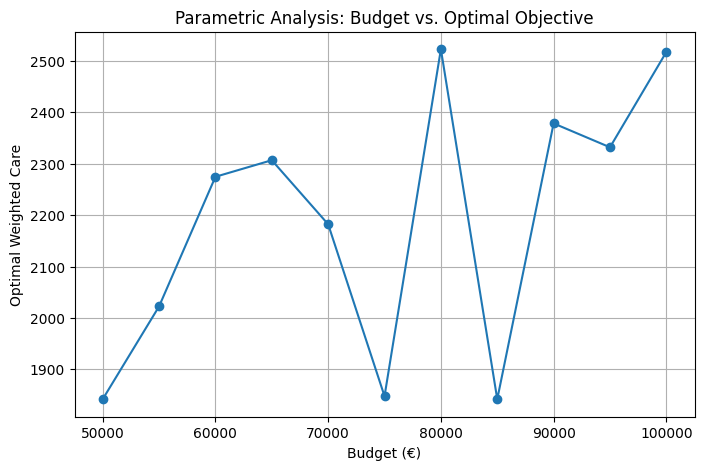

In [21]:
plt.figure(figsize=(8,5))
plt.plot(list(budgets), optimal_values, marker='o')
plt.xlabel('Budget (€)')
plt.ylabel('Optimal Weighted Care')
plt.title('Parametric Analysis: Budget vs. Optimal Objective')
plt.grid(True)
plt.show()

The plot provides meaningful conclusions to be drawn from it, such as:
- The slope represents the marginal benefit, so that if the slope would have been constant, then it will show that every inverted euro on the budget will perform as the one before, but if the curve was concave, then it will respond to the Law of Disminishing Returns, so that as long as the budget increases, the model starts covering less profitable necessities, for example.
- The graph is constantly changing due to the budget and other restrictions. There is a growing phase in which the curve increases, specially between 50000 and 70000 €, so that the budget is an active constraint. However, in the plateau phase, after 80000 €, it is observed that the budget does not drastically increase despite more money is added, so that the budget is a slack and the real constraint is now the workers capacity or even that all the patient demand has been covered.
- The model will always prioritize the assignment of budget to the combinations where weight and efficiency are higher. Because of being a MILP model, there are some sharp increases in the curve where the budget must increase enough to activate a full 8-hour shift for an additional staff member.

Conclusively, it would be recommended to cap the budget at 80000 €, as any investment beyond that point would result in an inefficient resource usage unless the hospital also invests in increasing staff capacity or improving medical efficiency.

## **Conclusions**

---

To conclude, the different formulations analyzed throughout this assignment provide a broad understanding of the staffing and shift assignment problem. The original MILP formulation originates an optimal solution that satisfies all operational constraints, while remaining computationally efficient, demonstrating that integrality requirements do not significantly impact solution time for the problem size considered. Also, the analysis of the relaxed MILP formulation, which incorporates a minimum working hours constraint through a Big-M approach, shows that relaxing the integrality constraints does not improve the objective value. The resulting zero integrality gap indicates that the MILP solution is tight and robust with respect to the imposed relaxation. Overall, the results confirm that the original MILP formulation is sufficient to capture the essential structure of the problem and produce high-quality solutions. The additional analysis through relaxation serves as a validation of the solution’s robustness, reinforcing confidence in the modeling approach and the optimality of the obtained results.